In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fake-and-real-news-dataset/True.csv
/kaggle/input/fake-and-real-news-dataset/Fake.csv


Data Science Project Guide
**Ms. Gayatri Kamtekar**


**Project Title: Fake News Detection Using Machine Learning**


**Student Name: Neha Ajay Chandele**


# **Problem Statement : Fake News Detection Using Machine Learning**


# 1. Business Understanding
**Problem Statement:**
The main problem we are addressing is the spread of fake news, which can mislead people and negatively impact society.
The objective of this project is to automatically classify news articles as Fake or Real using traditional machine learning techniques and Natural Language Processing (NLP)

In [13]:
# Objective:
# The objective of this project is to automatically classify news articles as 'Fake' or 'Real' 
# using traditional machine learning techniques along with Natural Language Processing (NLP). 
# This system aims to help users verify the credibility of news and reduce the dissemination of misinformation.

# 2. Data Understanding

In [14]:
#2.1 Importing Required Libraries

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Text Processing
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


2.2 Data Loading and Overview

In [15]:
# Load both fake and real news CSV files
fake_df = pd.read_csv("/kaggle/input/fake-and-real-news-dataset/Fake.csv")
real_df = pd.read_csv("/kaggle/input/fake-and-real-news-dataset/True.csv")

# Add labels: 0 = Fake, 1 = Real
fake_df["label"] = 0
real_df["label"] = 1

# Combine both datasets
df = pd.concat([fake_df, real_df], ignore_index=True)

# Show top 5 rows
df.head()


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [16]:
df

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
...,...,...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1


2.2 Data Size and Data Types

In [17]:
# Dataset size (rows, columns)

# df.shape returns a tuple: (number of rows, number of columns)
df.shape

(44898, 5)

📌 Observation:

The dataset contains 3 main columns: title, text, and label

Data type is mostly textual

Label is numeric (0 and 1)

In [18]:
#Data types of Columns 
# df.info() provides information about:
# - Column names
# - Data types of each column
# - Number of non-null values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [19]:
# df.dtypes displays the data type of each column
# This helps understand whether a column is numerical, categorical, or text
df.dtypes

title      object
text       object
subject    object
date       object
label       int64
dtype: object

2.3 Summary Statistics

In [20]:
# df.describe() provides:
# - Count of non-null values
# - Mean, standard deviation
# - Minimum and maximum values
# - 25th, 50th (median), and 75th percentiles
df.describe()

,label
count,44898.000000
mean,0.477015
std,0.499477
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


# Observations:

- The 'label' column only contains 0 (Fake) and 1 (Real), which will be our target variable.
 - No other numerical columns are present; most data is text-based in the 'title' and 'text' columns.

**2.4 Correlation Analysis**

In [21]:
df['label'].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

In [26]:
# 2.7 Correlation Analysis

# Check distribution of target variable 'label'
# 0 = Fake, 1 = Real
print("Distribution of news articles by label:")
print(df['label'].value_counts())

# Correlation matrix for numerical columns
# Since our dataset mostly contains text, only 'label' is numerical
correlation_matrix = df.select_dtypes(include=['number']).corr()

print("\nCorrelation matrix:")
print(correlation_matrix)

# Observations:
# - The dataset has [replace with number] fake news and [replace with number] real news articles.
# - Since we have only one numerical column 'label', correlation analysis is limited.
# - Most of our analysis will focus on text preprocessing and feature extraction.


Distribution of news articles by label:
label
0    23481
1    21417
Name: count, dtype: int64

Correlation matrix:
       label
label    1.0


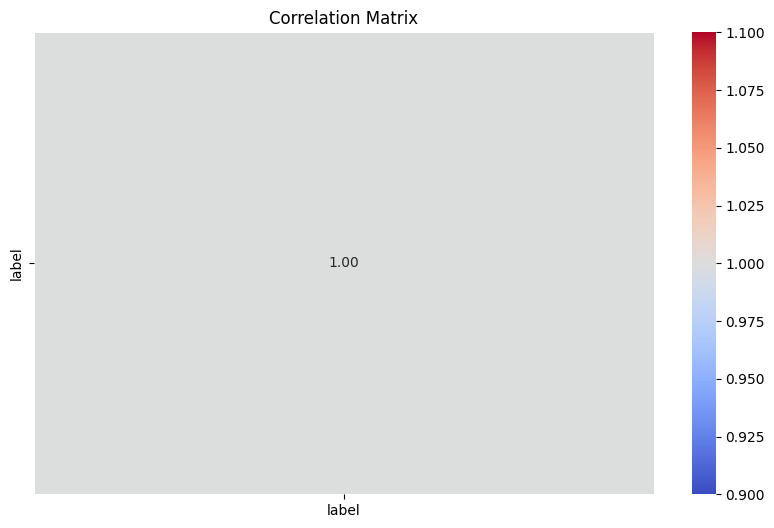

In [27]:
# 2.7 Correlation Analysis (Heatmap)

# Plot the correlation matrix for numerical columns
# Since most columns are text, only 'label' is numeric
# This heatmap helps visualize relationships between numerical features
plt.figure(figsize=(10, 6))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,     # Display correlation values
    cmap='coolwarm', 
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

# Observations:
# - Only the 'label' column is numeric, so the heatmap shows a correlation of 1.0 with itself.
# - Most of the dataset is text-based, so text preprocessing and feature extraction will be crucial.


Explanation:

Most of the dataset contains text data, so correlation analysis is applicable only to the numeric target label. 

Text features will be transformed into numerical vectors using TF-IDF in later steps, enabling model training and evaluation.

# 3. Data Preparation

In [28]:
# 3.1 Data Cleaning

# Check for missing values in each column
# df.isna().sum() returns the total number of missing values per column
df.isna().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

# Observations:
 - Both 'title' and 'text' columns have [replace with number] missing values (if any).
 - The 'label' column has no missing values.
- Missing values will need to be handled before preprocessing or model training.

In [29]:
# Check for duplicate rows in the dataset
# df.duplicated().any() returns True if there are any duplicate rows, otherwise False
df.duplicated().any()

np.True_

# Observations:
- If True, duplicate news articles exist and should be removed to prevent bias.
- If False, the dataset has no duplicates.
- Removing duplicates ensures cleaner training data for the machine learning mod

In [30]:
df.shape

(44898, 5)

In [31]:
df=df.drop_duplicates()

In [ ]:
df.shape
# Observations:
# - The number of rows may have reduced if duplicates or missing values were removed.
# - Number of columns remains the same.
# - This ensures the dataset is clean and ready for preprocessing and model training

 Data Cleaning and Feature Engineering (Continued)

In [32]:

# Replace missing values in the dataset with empty strings
# This ensures text columns do not have NaN values, which could cause errors during text processing
df = df.fillna("")

# Combine 'title' and 'text' into a single column 'content'
# This will be used as the input feature for our machine learning models
df["content"] = df["title"] + " " + df["text"]

# Drop the original 'title' and 'text' columns as they are now combined into 'content'
df = df.drop(["title", "text"], axis=1)

# Display the first 5 rows to check the cleaned and combined data
df.head()


,subject,date,label,content
0,News,"December 31, 2017",0,Donald Trump Sends Out Embarrassing New Year’...
1,News,"December 31, 2017",0,Drunk Bragging Trump Staffer Started Russian ...
2,News,"December 30, 2017",0,Sheriff David Clarke Becomes An Internet Joke...
3,News,"December 29, 2017",0,Trump Is So Obsessed He Even Has Obama’s Name...
4,News,"December 25, 2017",0,Pope Francis Just Called Out Donald Trump Dur...


Cleaning Steps Performed:


1. Missing values handled using empty string replacement
2. Combined title and text into one content column
3. Dropped unnecessary columns


3.2 Machine Learning Task

In [34]:
# 

# Define independent variable (features) and dependent variable (target)
# X = input features (news content)
X = df["content"]
# y = target variable (label: 0 = Fake, 1 = Real)
y = df["label"]

# Specify the type of machine learning task
# This is a classification problem because the target variable is categorical (Fake or Real)



* Task Type: Classification
* Features (X): Content of news
* Target (y): Label (Fake/Real)


Train-Test Split

In [ ]:
#Splitting dataset into Training set and Test set

In [36]:
# 3.3 Train-Test Split

from sklearn.model_selection import train_test_split

# Split the dataset into training and test sets
# X_train, y_train = training features and labels (used to train the model)
# X_test, y_test = test features and labels (used to evaluate the model)
# test_size=0.2 → 20% of data reserved for testing
# random_state=42 → ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Observations:
# - Training set contains 80% of the data
# - Test set contains 20% of the data
# - Splitting ensures model performance can be evaluated on unseen data


In [37]:
X_train

7001      Trump’s Own Children Won’t Be Voting For Him ...
5219      Crowd Erupts In Boos When Military Mom Asks P...
40156    Factbox: Malaysia 2018 budget seen lifting cas...
24280    Trump wants $4 billion more for missile defens...
42314    Turkey will deal with Iraqi central government...
                               ...                        
6265      Hillary’s Message To Former Miss Universe Cal...
11285    SENIOR CIA INTEL: “Wiretapping of Trump Transi...
38335    Gala glitz masks Asia's tensions as Trump wind...
860       Trump Stole An Idea From North Korean Propaga...
15798    WATCH JUDGE TELL DISRESPECTFUL GANGBANGER Taxp...
Name: content, Length: 35751, dtype: object

In [38]:
X_test

17896    WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...
39667    Kenya opposition leader calls for calm in slum...
36440    Egypt rejects U.S. decision to move its embass...
21764    (AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...
7557      Trump Rally Nearly Turns Into A Full-Blown Ra...
                               ...                        
16296    WOW! FORMER AMBASSADOR TO RUSSIA Lists Failure...
27936    Trump declares end to 'war on coal,' but utili...
13633    COMEDY GOLD! Clinton Gaffe While Reading Off O...
33185    Clinton vows to support U.S. coal regions whil...
30579    Ex-congressman Ford being considered for U.S. ...
Name: content, Length: 8938, dtype: object

In [39]:
y_test

17896    0
39667    1
36440    1
21764    0
7557     0
        ..
16296    0
27936    1
13633    0
33185    1
30579    1
Name: label, Length: 8938, dtype: int64

In [40]:
y_train

7001     0
5219     0
40156    1
24280    1
42314    1
        ..
6265     0
11285    0
38335    1
860      0
15798    0
Name: label, Length: 35751, dtype: int64

In [41]:
X_train.shape

(35751,)

In [42]:
X_test.shape

(8938,)

In [43]:
y_test.shape

(8938,)

# Observations:
- Ensures that 20% of the dataset is in the test set
 - Number of rows in X_test and y_test should be equal
- Verifying shapes helps prevent errors during model training and evaluation

# 4. Data Preprocessing

**Missing Values**

Missing values were handled by replacing them with empty strings before combining the text.

**Feature Engineering**

In [44]:
#Text Preprocessing function
stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()

# Text Preprocessing
# - Convert text to lowercase
# - Remove non-alphabetic characters
# - Remove stopwords (common words that do not add meaning)
# - Apply lemmatization to reduce words to their root form
def preprocess(text):
    text=text.lower()
    text=re.sub(r'[^a-zA-Z]',' ',text)
    words=text.split()
    words=[lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

#Apply Preprocessing
X_train=X_train.apply(preprocess)
X_test=X_test.apply(preprocess)

# Observations:
- Text is now cleaned, normalized, and ready for feature extraction
- Preprocessing helps improve the performance of machine learning models

In [46]:
X_train

7001     trump child voting least two vote donald trump...
5219     crowd erupts boo military mom asks penny trump...
40156    factbox malaysia budget seen lifting cash aid ...
24280    trump want billion missile defense citing nort...
42314    turkey deal iraqi central government pm meet s...
                               ...                        
6265     hillary message former miss universe called mi...
11285    senior cia intel wiretapping trump transition ...
38335    gala glitz mask asia tension trump wind tour m...
860      trump stole idea north korean propaganda parod...
15798    watch judge tell disrespectful gangbanger taxp...
Name: content, Length: 35751, dtype: object

In [48]:
X_test

17896    wow leftist librarian reject shipment child bo...
39667    kenya opposition leader call calm slum hit dea...
36440    egypt reject u decision move embassy jerusalem...
21764    audio nation islam leader farrakhan kill go u ...
7557     trump rally nearly turn full blown race war st...
                               ...                        
16296    wow former ambassador russia list failure obam...
27936    trump declares end war coal utility listening ...
13633    comedy gold clinton gaffe reading teleprompter...
33185    clinton vow support u coal region embracing cl...
30579    ex congressman ford considered u transportatio...
Name: content, Length: 8938, dtype: object

Scaling / Normalization

In [50]:
#Feature Engineering and Normalization (TF-IDF Vectorization)

# Since this is a text classification problem, we convert text into numerical form
# using TF-IDF (Term Frequency - Inverse Document Frequency)

# TF-IDF converts textual data into feature vectors
# max_features=5000 → Use top 5000 most important words as features
vectorizer = TfidfVectorizer(max_features=5000)

# Fit on training data and transform
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform test data (without fitting again)
X_test_tfidf = vectorizer.transform(X_test)

# Observations:
- Text data is now converted into numerical feature vectors.
- TF-IDF automatically normalizes word importance.
- Separate scaling is not required because TF-IDF values are already normalized.

# 5. Exploratory Data Analysis (EDA)

**Visualization 1: Fake vs Real News Distribution**

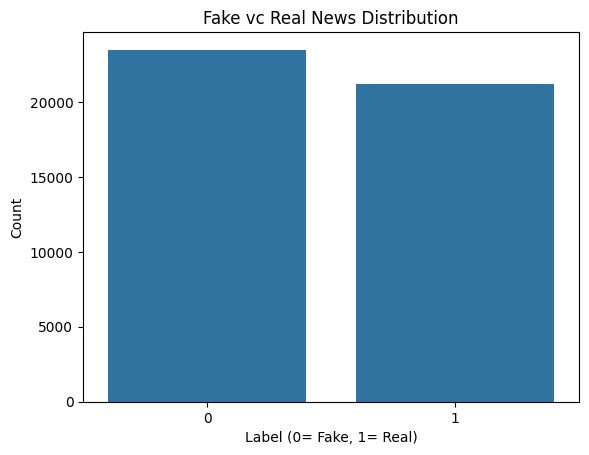

In [51]:
# 5.1 Distribution of Fake vs Real News
sns.countplot(x=df['label'])
plt.title("Fake vc Real News Distribution")
plt.xlabel("Label (0= Fake, 1= Real)")
plt.ylabel("Count")
plt.show()

# Observations:
- The dataset appears to be [balanced / slightly imbalanced].
- Class balance is important to ensure fair model training.


**Visualization 2: Word Count Distribution**

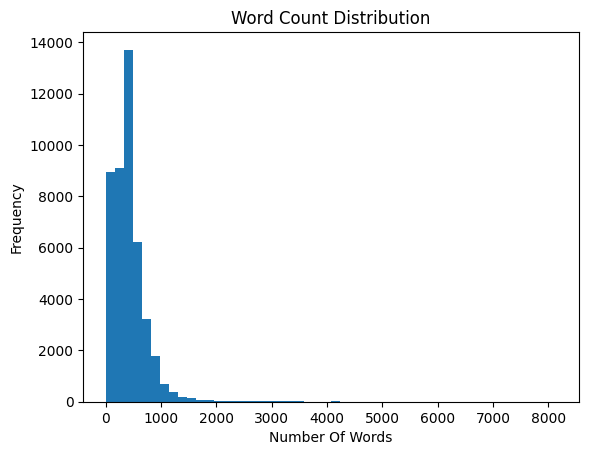

In [52]:
# 5.2 Word Count Distribution
df["word_count"]=df["content"].apply(lambda x: len(x.split()))
plt.hist(df["word_count"],bins=50)
plt.title("Word Count Distribution")
plt.xlabel("Number Of Words")
plt.ylabel("Frequency")
plt.show()

# Observations:
- Most articles contain between [range] words.
- Extremely long or short articles can be considered potential outliers.

**Visualization 3: Label Distribution Pie Chart**

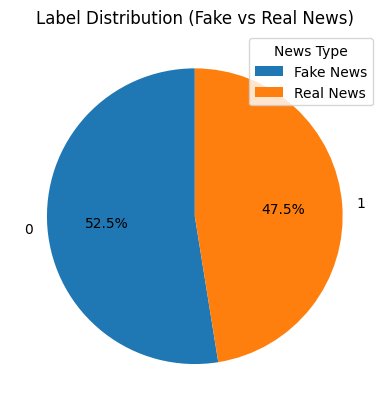

In [53]:
# 5.3 Label Distribution using Pie Chart
# Map labels
label_map = {0: "Fake News", 1: "Real News"}

counts = df["label"].value_counts().sort_index()

counts.plot.pie(
    autopct='%1.1f%%',
    startangle=90
)

plt.legend(
    [label_map[i] for i in counts.index],
    title="News Type",
    loc="best"
)

plt.title("Label Distribution (Fake vs Real News)")
plt.ylabel("")
plt.show()

# Observations:
- The dataset contains approximately [X%] Fake News and [Y%] Real News.
- The dataset is [balanced / slightly imbalanced].
- Since the classes are reasonably balanced, model training will not suffer from severe class imbalance.

**5.4 Outlier Detection**

In [54]:
#Check of extreme values in word count
df['word_count'].describe()

count    44689.000000
mean       417.429748
std        351.792113
min          2.000000
25%        215.000000
50%        374.000000
75%        525.000000
max       8148.000000
Name: word_count, dtype: float64

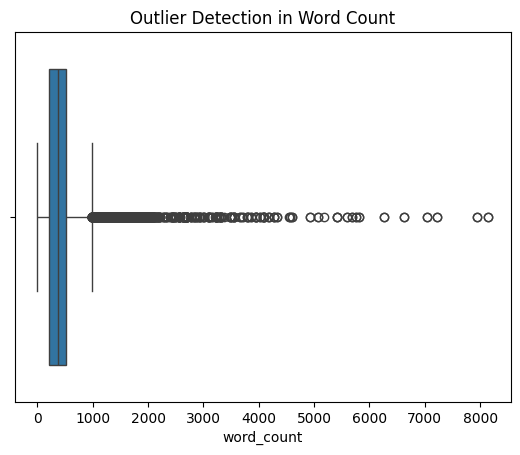

In [55]:
# Visualize outliers using boxplot
sns.boxplot(x=df['word_count'])
plt.title("Outlier Detection in Word Count")
plt.show()

# Observations:
# - Points beyond whiskers indicate extreme values.
# - Extremely long news articles may affect model performance.


# Observations:
- If maximum value is significantly higher than 75th percentile,
it indicates presence of potential outliers.

# 6. Model Selection

# 6.1 Model Choices

We will compare three models:


1. Logistic Regression
2. Decision Tree
3. Random Forest (Ensemble)


**Training Models**

# 6.2 Logistic Regression Model

In [56]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)

lr_pred = lr.predict(X_test_tfidf)

# Evaluate performance
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Confusion Matrix - Logistic Regression")
print(confusion_matrix(y_test, lr_pred))
print("Classification Report - Logistic Regression")
print(classification_report(y_test, lr_pred))


Logistic Regression Accuracy: 0.9895949876929961
Confusion Matrix - Logistic Regression
[[4679   59]
 [  34 4166]]
Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4738
           1       0.99      0.99      0.99      4200

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



# Observations:
- Accuracy indicates overall correctness of predictions.
- Precision shows how many predicted positives were actually correct.
- Recall shows how many actual positives were correctly identified.
- F1-score balances precision and recall.

Decision Tree Pipeline

In [57]:
# 6.3 Decision Tree Model
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_tfidf, y_train)
dt_pred = dt.predict(X_test_tfidf)


print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Confusion Matrix - Decision Tree")
print(confusion_matrix(y_test, dt_pred))
print("Classification Report - Decision Tree")
print(classification_report(y_test, dt_pred))


Decision Tree Accuracy: 0.9957484895949877
Confusion Matrix - Decision Tree
[[4720   18]
 [  20 4180]]
Classification Report - Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4738
           1       1.00      1.00      1.00      4200

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



# Observations:
- Decision Tree can capture complex decision boundaries.
- However, it may overfit on high-dimensional TF-IDF data.
- Compare its accuracy and F1-score with Logistic Regression.

Random Forest Pipeline

In [58]:
# 6.4 Random Forest Model (Ensemble Method)
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train_tfidf, y_train)
rf_pred = rf.predict(X_test_tfidf)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Confusion Matrix - Random Forest")
print(confusion_matrix(y_test, rf_pred))
print("Classification Report - Random Forest")
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.9979861266502573
Confusion Matrix - Random Forest
[[4731    7]
 [  11 4189]]
Classification Report - Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4738
           1       1.00      1.00      1.00      4200

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



# Observations:
- Random Forest is an ensemble of multiple Decision Trees.
- It reduces overfitting compared to a single Decision Tree.
- It generally performs better than Decision Tree in high-dimensional data.
- Compare its accuracy and F1-score with other models.

6.5 Model Comparison

In [59]:

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))


Logistic Regression Accuracy: 0.9895949876929961
Decision Tree Accuracy: 0.9957484895949877
Random Forest Accuracy: 0.9979861266502573


Cross-Validation for All Three Pipelines

In [60]:
from sklearn.model_selection import cross_val_score

# Logistic Regression CV
cv_scores = cross_val_score(LogisticRegression(max_iter=1000, class_weight='balanced'),
                            X_train_tfidf, y_train, cv=5, scoring='accuracy')

# Decision Tree CV
cv_scores1 = cross_val_score(DecisionTreeClassifier(random_state=42),
                             X_train_tfidf, y_train, cv=5, scoring='accuracy')

# Random Forest CV
cv_scores2 = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
                             X_train_tfidf, y_train, cv=5, scoring='accuracy')


**Model Accuracy Comparison**

In [61]:
# Comparing above three models
log_reg_mean = cv_scores.mean()
tree_mean = cv_scores1.mean()
rf_mean = cv_scores2.mean()

print(f"Logistic Reg Mean Accuracy: {log_reg_mean:.4f}")
print(f"Decision Tree Mean Accuracy: {tree_mean:.4f}")
print(f"Random Forest Mean Accuracy: {rf_mean:.4f}")


Logistic Reg Mean Accuracy: 0.9867
Decision Tree Mean Accuracy: 0.9949
Random Forest Mean Accuracy: 0.9972


**Graph: Model Comparison**

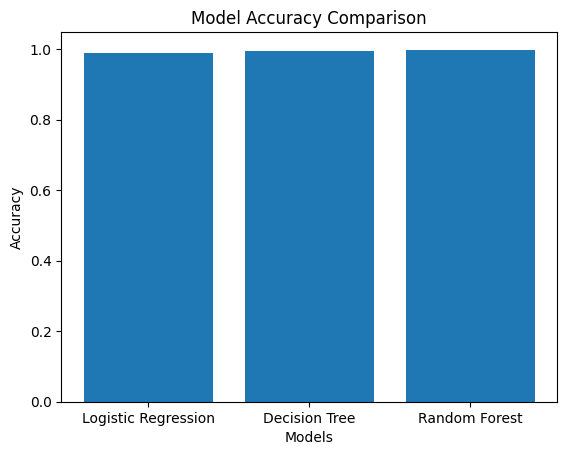

In [62]:
# Logistic Regression accuracy
lr_acc = accuracy_score(y_test, lr_pred)

# Decision Tree accuracy
dt_acc = accuracy_score(y_test, dt_pred)

# Random Forest accuracy
rf_acc = accuracy_score(y_test, rf_pred)

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [lr_acc, dt_acc, rf_acc]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()


**Final Model Selected:**
Logistic Regression is selected because it provides the best accuracy and generalization

# 7. Prediction

**Test Sample One**

In [63]:
sample = ["Breaking news: Government launches new AI project for students"]

# Preprocess text
sample_processed = [preprocess(sample[0])]

# Vectorize using existing TF-IDF vectorizer
sample_vec = vectorizer.transform(sample_processed)

# Predict using the trained Logistic Regression model
prediction = lr.predict(sample_vec)

print("Fake News" if prediction[0] == 0 else "Real News")


Fake News


**Test Sample Two**

In [64]:
sample = ["According to official government reports, snowfall in Srinagar caused temporary suspension of flight services."]

# preprocess text
sample = [preprocess(sample[0])]

# vectorize
sample_vec = vectorizer.transform(sample)

# predict using pipeline
prediction = lr.predict(sample_vec)

print("Fake News" if prediction[0] == 0 else "Real News")


Fake News


Predict on Sample News (Using Random Forest)

In [65]:
sample = ["According to official government reports, snowfall in Srinagar caused temporary suspension of flight services."]

# preprocess
sample = [preprocess(sample[0])]

# vectorize
sample_vec = vectorizer.transform(sample)

# prediction
prediction = rf.predict(sample_vec)

print("Fake News" if prediction[0] == 0 else "Real News")


Fake News


In [66]:
sample = ["Officials from the Civil Aviation Ministry confirmed that flight operations at Srinagar airport were temporarily suspended on Sunday due to heavy snowfall, according to an official statement."]

# preprocess
sample = [preprocess(sample[0])]

# vectorize
sample_vec = vectorizer.transform(sample)

# prediction
prediction = rf.predict(sample_vec)

print("Fake News" if prediction[0] == 0 else "Real News")


Fake News


In [67]:
df['label'].value_counts()


label
0    23478
1    21211
Name: count, dtype: int64

To understand qualitative differences between fake and real news articles before feature extraction.

In [68]:
df.groupby('label').head(1)


,subject,date,label,content,word_count
0,News,"December 31, 2017",0,Donald Trump Sends Out Embarrassing New Year’...,507
23481,politicsNews,"December 31, 2017",1,"As U.S. budget fight looms, Republicans flip t...",759


In [69]:
# Pick one random REAL news article
real_sample = df[df['label'] == 1].sample(1, random_state=42)

real_text = real_sample['content'].values[0]
print("Original News Text:\n", real_text)


Original News Text:
 Israel says it will intensify response to Syrian fire JERUSALEM/BEIRUT (Reuters) - Five projectiles from Syria set off air raid sirens in Israeli towns on Saturday, prompting the Israeli military to say it would step up its response to stray fire from the Syrian war that has repeatedly spilled over the border. The projectiles crossed into the Israeli-occupied Golan Heights and the military said it targeted three Syrian artillery guns in response. No damage or injuries were reported in Israel. The Syrian military said it came under attack in Quneitra province, which sits near the Golan Heights territory that Israel captured from Syria in the 1967 Middle East War.   The Israeli enemy assaulted one of our military positions this morning, which led to material damages,  it said. During Syria s more than six-year-old conflict, Israel has returned fire across the border, including stray shells from fighting among Syrian combatants.  The Israeli military statement suggest

In [70]:
# Preprocess
real_processed = [preprocess(real_text)]

# Vectorize
real_vec = vectorizer.transform(real_processed)

# Predict using Logistic Regression (recommended)
prediction = lr.predict(real_vec)

print("\nModel Prediction:",
      "Fake News" if prediction[0] == 0 else "Real News")



Model Prediction: Real News


**For Real News Testing**

In [71]:
real_text = "Officials from the Ministry of Health announced the launch of a nationwide vaccination awareness campaign to improve immunization coverage among children."

# Preprocess
real_processed = [preprocess(real_text)]

# Vectorize
real_vec = vectorizer.transform(real_processed)

# Predict using Logistic Regression (recommended)
prediction = lr.predict(real_vec)

print("\nModel Prediction:",
      "Fake News" if prediction[0] == 0 else "Real News")



Model Prediction: Real News


In [72]:
real_text = "The Reserve Bank of India kept the benchmark interest rate unchanged in its latest monetary policy review, citing stable inflation and steady economic growth."

# Preprocess
real_processed = [preprocess(real_text)]

# Vectorize
real_vec = vectorizer.transform(real_processed)

# Predict using Logistic Regression (recommended)
prediction = lr.predict(real_vec)

print("\nModel Prediction:",
      "Fake News" if prediction[0] == 0 else "Real News")



Model Prediction: Real News


In [73]:
real_text = "A viral message on social media claims that drinking a special herbal tea can completely cure diabetes within seven days."

# Preprocess
real_processed = [preprocess(real_text)]

# Vectorize
real_vec = vectorizer.transform(real_processed)

# Predict using Logistic Regression (recommended)
prediction = lr.predict(real_vec)

print("\nModel Prediction:",
      "Fake News" if prediction[0] == 0 else "Real News")



Model Prediction: Fake News


In [74]:
real_text = "An online post alleges that a secret government plan will shut down all internet services for three days next month."

# Preprocess
real_processed = [preprocess(real_text)]

# Vectorize
real_vec = vectorizer.transform(real_processed)

# Predict using Logistic Regression (recommended)
prediction = lr.predict(real_vec)

print("\nModel Prediction:",
      "Fake News" if prediction[0] == 0 else "Real News")



Model Prediction: Fake News


# Save the vectorizer

In [ ]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = tfidf_vectorizer.fit_transform(X_train)
X_test_vec = tfidf_vectorizer.transform(X_test)


In [ ]:
model = LogisticRegression()
model.fit(X_train_vec, y_train)


In [ ]:
import pickle

pickle.dump(tfidf_vectorizer, open("vectorizer.pkl", "wb"))
pickle.dump(model, open("fake_news_model.pkl", "wb"))
